# Remote Scanner Demo
Scan a remote aquarium MP4 via ffmpeg streaming — no full download.
Scores frames with CLIP, then downloads only octopus-containing segments.

In [1]:
import sys
import os
import logging
sys.path.append('..')
os.chdir('..')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

from phase2.remote_scanner import RemoteScanner, list_camera_urls, scan_url, download_segment
from phase2.scanner import load_clip, detect_segments

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)

/Users/siddharthraj/Documents/my-projects/sentiment-analysis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. List available videos for a date

In [2]:
DATE = '2026-02-20'

camera_urls = list_camera_urls(DATE)

for cam, urls in camera_urls.items():
    print(f'{cam:<15}  {len(urls)} videos')

13:24:28 [INFO] phase2.remote_scanner: Left Top         31 videos on 2026-02-20
13:24:29 [INFO] phase2.remote_scanner: Right Back       31 videos on 2026-02-20
13:24:29 [INFO] phase2.remote_scanner: Right Front      31 videos on 2026-02-20
13:24:30 [INFO] phase2.remote_scanner: Right Left       31 videos on 2026-02-20
13:24:31 [INFO] phase2.remote_scanner: Right Right      31 videos on 2026-02-20
13:24:31 [INFO] phase2.remote_scanner: Right Top        31 videos on 2026-02-20


Left Top         31 videos
Right Back       31 videos
Right Front      31 videos
Right Left       31 videos
Right Right      31 videos
Right Top        31 videos


## 2. Pick one video to scan

In [3]:
# pick Left Top camera, midday recording
CAMERA  = 'Left Top'
VIDEO_URL = camera_urls[CAMERA][len(camera_urls[CAMERA]) // 2]  # middle of the day
print(f'Scanning: {VIDEO_URL}')

Scanning: https://repo.octopus-intelligence.org/public/O-vulgaris-Nity-2026-2-20--/Left%20Top/Local/2026-02-20/162422--vv-1.mp4


## 3. Load CLIP and scan (no full download)

In [4]:
import time

model, processor, text_features, device = load_clip()
print(f'Device: {device}')

t0 = time.perf_counter()
timestamps, scores = scan_url(VIDEO_URL, model, processor, text_features, device)
elapsed = time.perf_counter() - t0

print(f'\nScanned   : {len(scores)} seconds')
print(f'Wall time : {elapsed:.1f}s')
print(f'Per frame : {elapsed / len(scores) * 1000:.0f}ms')
print(f'Score range: {scores.min():.3f} – {scores.max():.3f}  |  mean: {scores.mean():.3f}')

13:24:31 [INFO] phase2.scanner: Loading CLIP on cpu ...
13:24:32 [INFO] phase2.scanner: CLIP loaded in 1.0s
13:24:32 [INFO] phase2.remote_scanner: Scanning remote: https://repo.octopus-intelligence.org/public/O-vulgaris-Nity-2026-2-20--/Left%20Top/Local/2026-02-20/162422--vv-1.mp4
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Device: cpu


13:24:36 [INFO] phase2.remote_scanner: Remote video duration: 1796.0s
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
13:24:47 [INFO] phase2.remote_scanner:   scored 31s of video
13:24:52 [INFO] phase2.remote_scanner:   scored 63s of video
13:24:59 [INFO] phase2.remote_scanner:   scored 95s of video
13:25:02 [INFO] phase2.remote_scanner:   scored 127s of video
13:25:07 [INFO] phase2.remote_scanner


Scanned   : 1796 seconds
Wall time : 316.3s
Per frame : 176ms
Score range: 0.010 – 0.749  |  mean: 0.102


## 4. Score timeline

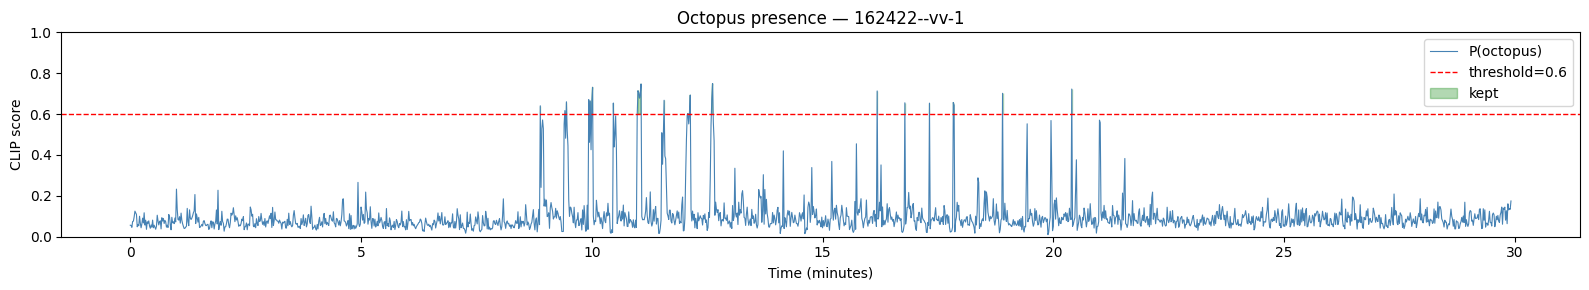

In [5]:
THRESHOLD = 0.6

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(timestamps / 60, scores, color='steelblue', linewidth=0.8, label='P(octopus)')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'threshold={THRESHOLD}')
ax.fill_between(timestamps / 60, scores, THRESHOLD,
                where=(scores >= THRESHOLD), alpha=0.3, color='green', label='kept')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('CLIP score')
ax.set_title(f'Octopus presence — {Path(VIDEO_URL).stem}')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Detect segments and download

In [6]:
segments = detect_segments(timestamps, scores, threshold=THRESHOLD, min_duration=5.0)

total_detected = sum(e - s for s, e in segments)
total_video    = float(timestamps[-1])

print(f'Segments detected : {len(segments)}')
print(f'Octopus footage   : {total_detected:.0f}s / {total_video:.0f}s  ({total_detected/total_video*100:.1f}%)')
print()
for i, (s, e) in enumerate(segments):
    print(f'  [{i:02d}]  {s/60:.1f}min → {e/60:.1f}min  ({e-s:.0f}s)')

Segments detected : 1
Octopus footage   : 5s / 1795s  (0.3%)

  [00]  11.0min → 11.1min  (5s)


In [7]:
OUT_DIR = Path('data/aquarium') / DATE / CAMERA.replace(' ', '_')
video_name = Path(VIDEO_URL).stem

downloaded = []
for i, (start, end) in enumerate(segments):
    out_path = OUT_DIR / f'{video_name}_{start:.0f}_{end:.0f}.mp4'
    if out_path.exists():
        print(f'[{i:02d}] Already exists: {out_path.name}')
        downloaded.append(out_path)
        continue
    print(f'[{i:02d}] Downloading {start:.0f}s–{end:.0f}s ...', end=' ', flush=True)
    p = download_segment(VIDEO_URL, start, end, out_path)
    downloaded.append(p)
    print(f'{p.stat().st_size/1e6:.1f}MB')

total_mb = sum(p.stat().st_size for p in downloaded) / 1e6
print(f'\nTotal downloaded: {total_mb:.1f}MB  ({len(downloaded)} segments)')

[00] Downloading 660s–665s ... 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
13:29:54 [INFO] phase2.remote_scanner: Downloaded 660.0–665.0s → data/aquarium/2026-02-20/Left_Top/162422--vv-1_660_665.mp4  (2.7MB, 5.7s)


2.7MB

Total downloaded: 2.7MB  (1 segments)


## 6. Preview downloaded segments

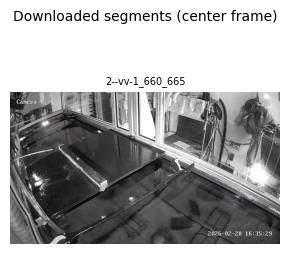

In [8]:
def grab_frame(video_path, frac=0.5):
    cap = cv2.VideoCapture(str(video_path))
    total = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * frac))
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None

n = min(len(downloaded), 8)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
if n == 1: axes = [axes]

for ax, path in zip(axes, downloaded[:n]):
    frame = grab_frame(path)
    if frame is not None:
        ax.imshow(frame)
    ax.set_title(path.stem[-15:], fontsize=7)
    ax.axis('off')

plt.suptitle('Downloaded segments (center frame)', fontsize=10)
plt.tight_layout()
plt.show()